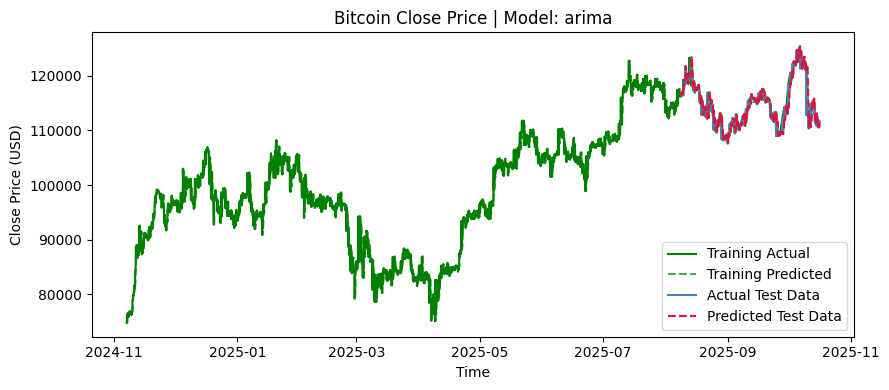

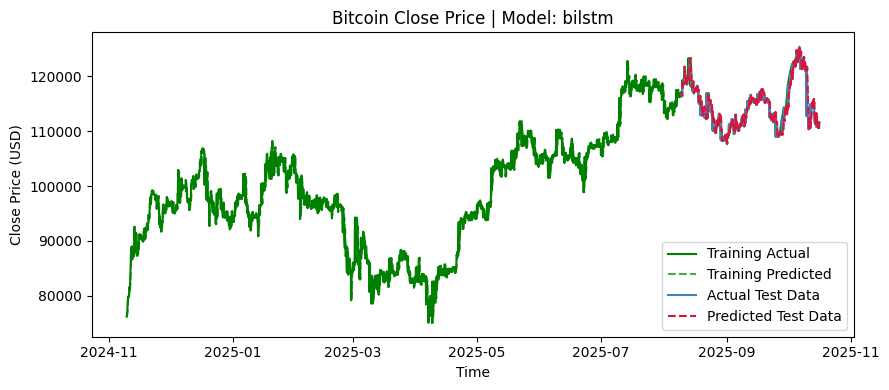

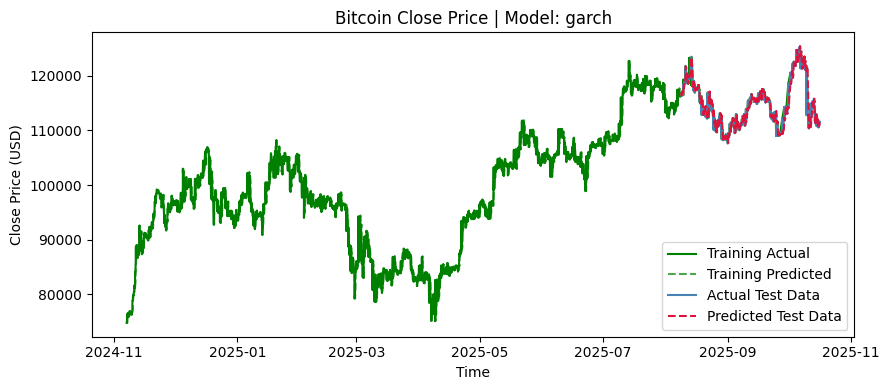

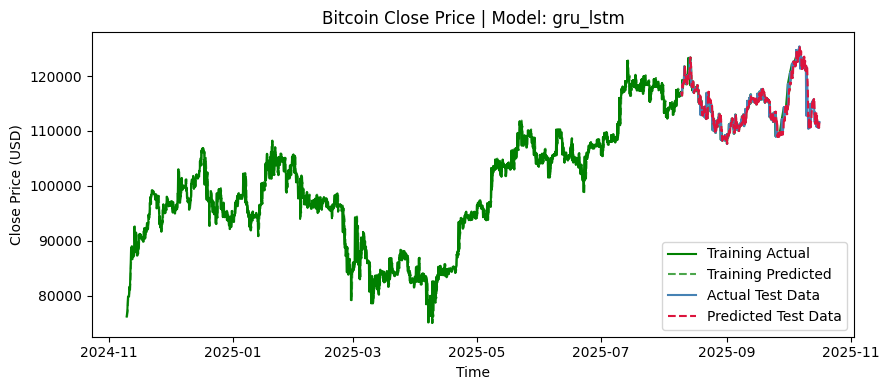

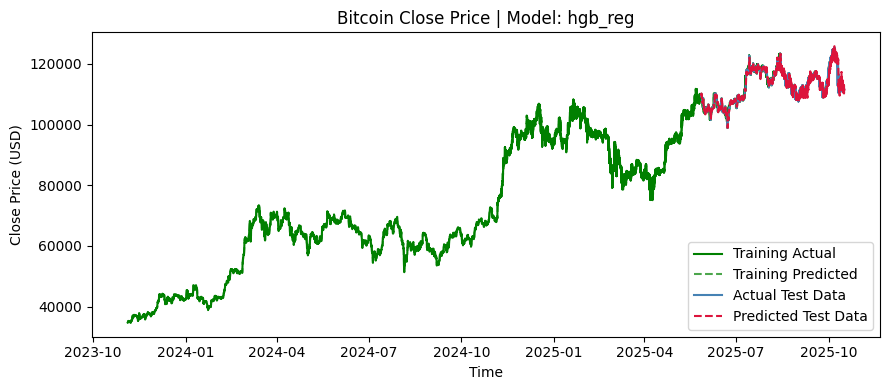

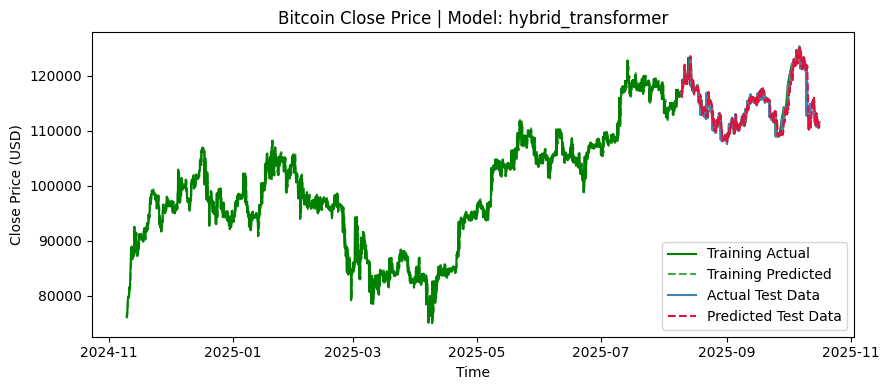

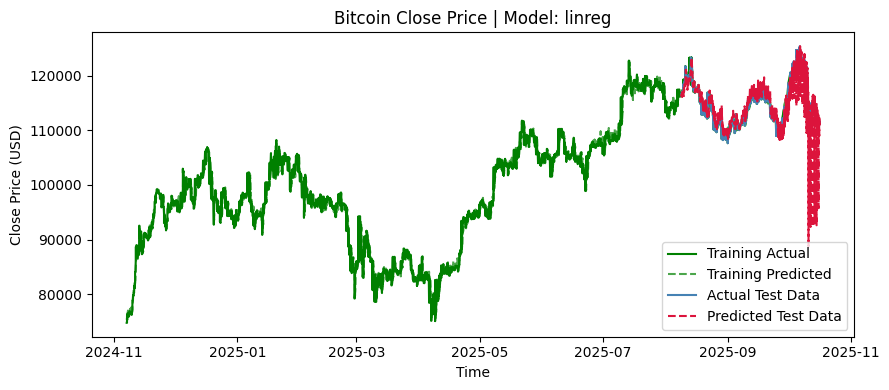

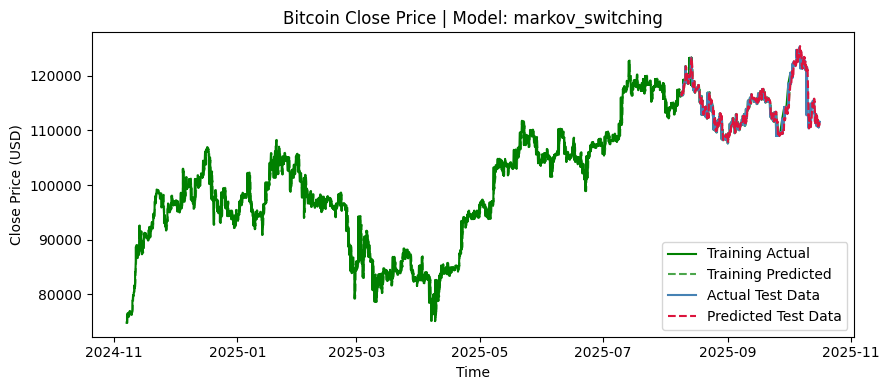

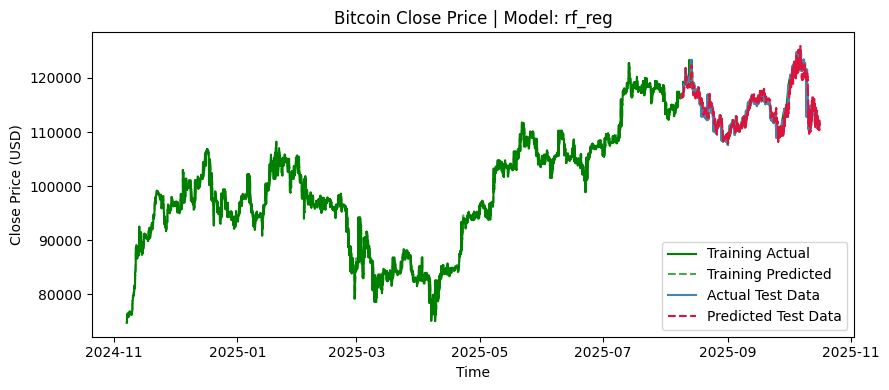

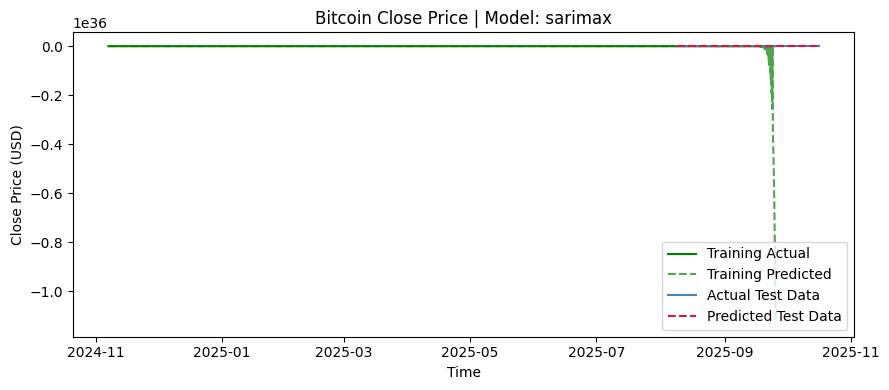

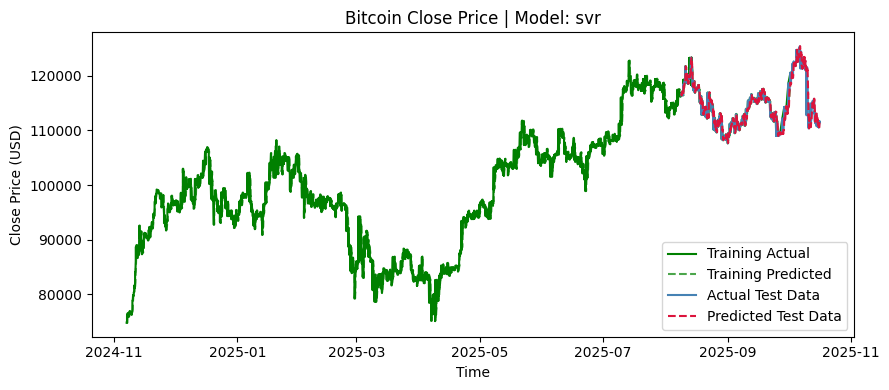

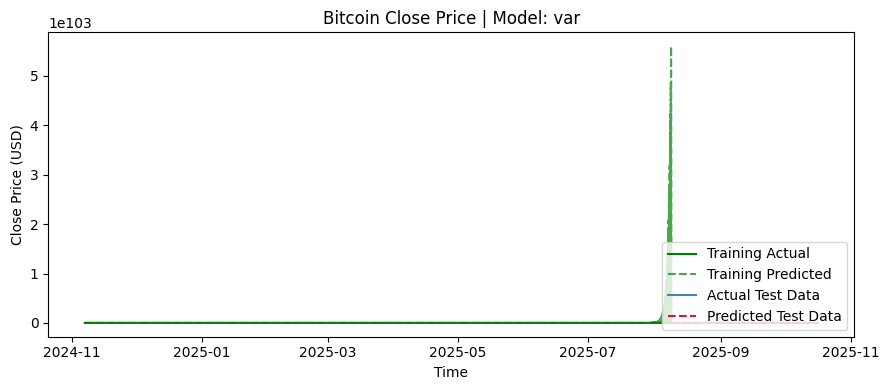

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PRICE_DIR = Path("backtest_output/predictions")
price_files = sorted(PRICE_DIR.glob("PRICE_*.csv"))
if not price_files:
    raise FileNotFoundError(
        "No PRICE_*.csv files found in backtest_output/predictions. Run a backtest to generate price tracks."
    )

frames = []
for path in price_files:
    df = pd.read_csv(path)
    df["source_file"] = path.name
    frames.append(df)

combined_results = pd.concat(frames, ignore_index=True)
combined_results["Model"] = combined_results["model"].astype(str)
combined_results["Type"] = combined_results["split"].str.capitalize()
combined_results["Actual"] = combined_results["actual_next_close"].astype(float)
combined_results["Predicted"] = combined_results["predicted_next_close"].astype(float)
combined_results["Timestamp"] = (
    pd.to_datetime(combined_results["target_time_ms"], unit="ms", errors="coerce", utc=True)
    .dt.tz_localize(None)
)

# ensure consistent ordering and drop rows lacking timestamps
combined_results = combined_results.dropna(subset=["Timestamp"])
combined_results = combined_results.sort_values(["Model", "Timestamp"]).reset_index(drop=True)

def plot_model_price_series(model_name: str, results: pd.DataFrame, train_label: str = "Train", test_label: str = "Test") -> None:
    model_df = results[results["Model"] == model_name].copy()
    if model_df.empty:
        print(f"[WARN] No rows found for model '{model_name}'. Skipping plot.")
        return
    model_df = model_df.set_index("Timestamp")

    lower_train = model_df["Type"].str.lower() == train_label.lower()
    lower_test = model_df["Type"].str.lower() == test_label.lower()

    train_actual = model_df.loc[lower_train, "Actual"]
    train_pred = model_df.loc[lower_train, "Predicted"]
    test_actual = model_df.loc[lower_test, "Actual"]
    test_pred = model_df.loc[lower_test, "Predicted"]

    plt.figure(figsize=(9, 4))
    if not train_actual.empty:
        plt.plot(train_actual.index, train_actual.values, label="Training Actual", color="green")
    if not train_pred.empty:
        plt.plot(train_pred.index, train_pred.values, label="Training Predicted", color="green", linestyle="dashed", alpha=0.7)
    if not test_actual.empty:
        plt.plot(test_actual.index, test_actual.values, label="Actual Test Data", color="steelblue")
    if not test_pred.empty:
        plt.plot(test_pred.index, test_pred.values, label="Predicted Test Data", color="crimson", linestyle="dashed")
    plt.title(f"Bitcoin Close Price | Model: {model_name}")
    plt.xlabel("Time")
    plt.ylabel("Close Price (USD)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

regressor_models = sorted(combined_results["Model"].unique())
for model in regressor_models:
    plot_model_price_series(model, combined_results)

In [ ]:
# Cell 2: Test-only plots (Actual vs Predicted) for each model
for model in regressor_models:
    model_test = combined_results[
        (combined_results["Model"] == model) & (combined_results["Type"].str.lower() == "test")
] .copy()
    if model_test.empty:
        print(f"[WARN] No test rows for model '{model}'. Skipping test-only plot.")
        continue
    # ensure Timestamp index
    model_test = model_test.set_index("Timestamp").sort_index()
    actual = model_test["Actual"].astype(float)
    predicted = model_test["Predicted"].astype(float)

    plt.figure(figsize=(10, 4))
    plt.plot(actual.index, actual.values, label="Actual Test Close", color="steelblue")
    plt.plot(predicted.index, predicted.values, label="Predicted Test Close", color="crimson", linestyle="dashed")
    plt.title(f"Test Window: Actual vs Predicted Close — Model: {model}")
    plt.xlabel("Time")
    plt.ylabel("Close Price (USD)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()